# 感知机（1958）— 动手实现

配套文档：[docs/01-perceptron-1958.md](../docs/01-perceptron-1958.md)

**目标**：从零手撕感知机算法，理解它能做什么、不能做什么。

**你需要懂**：基础 Python + 基础代数（不需要微积分）

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
print('依赖库加载完成:', 'numpy', np.__version__)

依赖库加载完成: numpy 1.26.4


## 第一步：实现感知机

我们从零实现。核心逻辑只有三件事：
1. **预测**：加权求和 → 阶跃函数
2. **学习**：比较预测和真相 → 调整权重
3. **重复**：直到全部预测正确（或达到最大轮数）

下面是我们要用的感知机代码（保存在 `src/perceptron.py`，可以直接打开查看）：

```python
class Perceptron:
    def __init__(self, learning_rate=0.1, max_epochs=100):
        self.lr = learning_rate
        self.max_epochs = max_epochs
        self.weights = None
        self.bias = None
        self.history = []  # 记录每轮的错误数

    def _step(self, z):
        return (z >= 0).astype(int)  # z>=0 -> 1, z<0 -> 0

    def predict(self, X):
        X = np.atleast_2d(X)
        z = X @ self.weights + self.bias
        return self._step(z)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.history = []
        for epoch in range(self.max_epochs):
            errors = 0
            for xi, yi in zip(X, y):
                pred = self.predict(xi)[0]
                error = int(yi) - int(pred)  # 误差 = 真相 - 预测
                if error != 0:
                    self.weights += self.lr * error * xi
                    self.bias    += self.lr * error
                    errors += 1
            self.history.append(errors)
            if errors == 0:
                print(f'收敛！第 {epoch + 1} 轮，错误数降到 0')
                return self
        print(f'达到最大轮数 {self.max_epochs}，停止训练（可能未收敛）')
        return self

    def accuracy(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y)
```

> **动手提示**：想改代码？打开 `src/perceptron.py`，改完后重新运行这个 notebook 就能看到效果。


In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.perceptron import Perceptron
print('Perceptron 类定义完成')

Perceptron 类定义完成


## 第二步：AND 门（感知机能搞定）

AND 门规则：只有两个输入都是 1，输出才是 1。

用坐标轴想：四个点在平面上，我们要找一条线把 `(1,1)` 和其他三个点分开。

In [3]:
# AND 真值表
X_and = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]], dtype=float)
y_and = np.array([0, 0, 0, 1])  # 只有 (1,1) 输出 1

# 训练感知机
p_and = Perceptron(learning_rate=0.1, max_epochs=50)
p_and.fit(X_and, y_and)

# 查看结果
preds = p_and.predict(X_and)
print(f'AND 预测: {preds}')
print(f'AND 真值: {y_and}')
print(f'准确率:   {p_and.accuracy(X_and, y_and) * 100:.0f}%')
print(f'学到的权重: w={p_and.weights}, b={p_and.bias:.2f}')

收敛！第 4 轮，错误数降到 0
AND 预测: [0 0 0 1]
AND 真值: [0 0 0 1]
准确率:   100%
学到的权重: w=[0.2 0.1], b=-0.20


/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_97657/2840400383.py:42: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_97657/2840400383.py:42: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_97657/2840400383.py:42: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_97657/2840400383.py:42: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_97657/2840400383.py:42: UserWarning: Glyph 34013 (\N{CJK UNIFIED IDEOGRAPH-84DD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4g

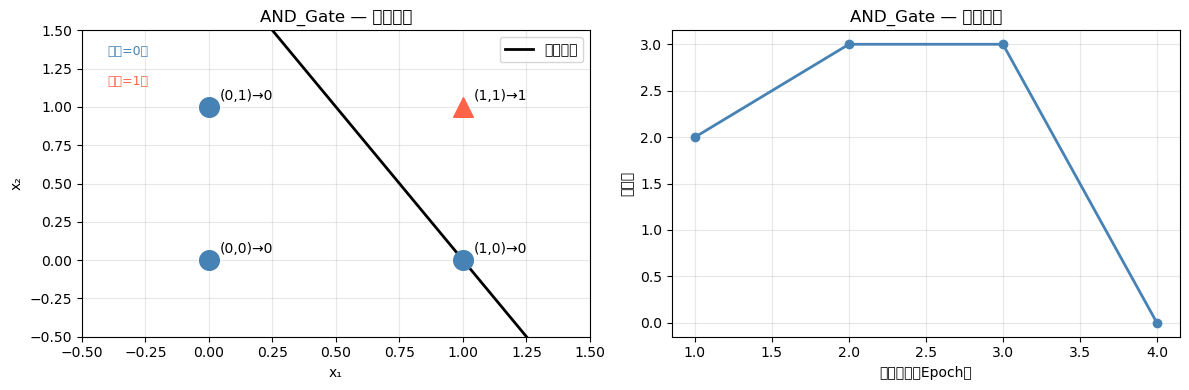

图片已保存


In [4]:
def plot_decision_boundary(model, X, y, title):
    """画出感知机的决策边界（那条分隔线）"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 左图：决策边界
    ax = axes[0]
    colors = ['steelblue' if yi == 0 else 'tomato' for yi in y]
    markers = ['o' if yi == 0 else '^' for yi in y]
    for xi, yi, c, m in zip(X, y, colors, markers):
        ax.scatter(xi[0], xi[1], color=c, marker=m, s=200, zorder=5)
        ax.annotate(f'({xi[0]:.0f},{xi[1]:.0f})→{yi}',
                    (xi[0], xi[1]), textcoords='offset points',
                    xytext=(8, 5), fontsize=10)

    # 画决策线：w0*x0 + w1*x1 + b = 0  => x1 = -(w0*x0 + b) / w1
    w = model.weights
    if abs(w[1]) > 1e-10:  # 避免除以零
        x0_range = np.linspace(-0.5, 1.5, 100)
        x1_line = -(w[0] * x0_range + model.bias) / w[1]
        ax.plot(x0_range, x1_line, 'k-', linewidth=2, label='决策边界')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.set_title(f'{title} — 决策边界')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.annotate('蓝色=0类', xy=(0.05, 0.92), xycoords='axes fraction',
                color='steelblue', fontsize=9)
    ax.annotate('红色=1类', xy=(0.05, 0.82), xycoords='axes fraction',
                color='tomato', fontsize=9)

    # 右图：学习曲线（每轮错误数）
    ax2 = axes[1]
    ax2.plot(range(1, len(model.history) + 1), model.history,
             'o-', color='steelblue', linewidth=2)
    ax2.set_xlabel('训练轮数（Epoch）')
    ax2.set_ylabel('错误数')
    ax2.set_title(f'{title} — 学习曲线')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'../figures/{title.replace(" ", "_")}.png', dpi=80,
                bbox_inches='tight')
    plt.show()
    print(f'图片已保存')


import os
os.makedirs('../figures', exist_ok=True)
plot_decision_boundary(p_and, X_and, y_and, 'AND_Gate')

## 第三步：XOR 门（感知机的极限）

XOR 规则：两个输入**不同**时输出 1，**相同**时输出 0。

在坐标平面上，XOR 的四个点是：
- `(0,0)→0` 和 `(1,1)→0`（对角线上）
- `(0,1)→1` 和 `(1,0)→1`（另一条对角线上）

你能找到一条直线把这两组点分开吗？答案是：**找不到**。

In [5]:
# XOR 真值表
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])  # 不同才输出 1

# 训练感知机（会达到最大轮数，无法收敛）
p_xor = Perceptron(learning_rate=0.1, max_epochs=100)
p_xor.fit(X_xor, y_xor)

preds_xor = p_xor.predict(X_xor)
print(f'XOR 预测: {preds_xor}')
print(f'XOR 真值: {y_xor}')
print(f'准确率:   {p_xor.accuracy(X_xor, y_xor) * 100:.0f}%  ← 最多 75%，因为一个点永远分错')
print(f'最后几轮错误数: {p_xor.history[-5:]}')

达到最大轮数 100，停止训练（可能未收敛）
XOR 预测: [1 1 0 0]
XOR 真值: [0 1 1 0]
准确率:   50%  ← 最多 75%，因为一个点永远分错
最后几轮错误数: [4, 4, 4, 4, 4]


/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_97657/1726004553.py:26: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_97657/1726004553.py:26: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_97657/1726004553.py:26: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_97657/1726004553.py:26: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_97657/1726004553.py:26: UserWarning: Glyph 26465 (\N{CJK UNIFIED IDEOGRAPH-6761}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4g

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26465 (\N{CJK UNIFIED IDEOGRAPH-6761}) missing from font(s) DejaV

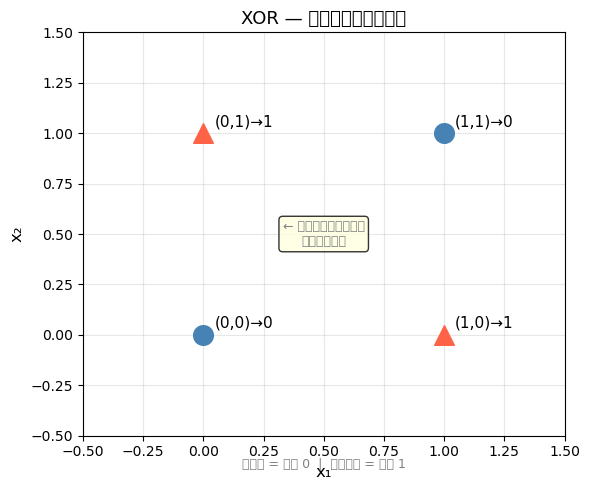

图片已保存


In [6]:
# 可视化 XOR 的"不可分"本质
fig, ax = plt.subplots(figsize=(6, 5))

colors_xor = ['steelblue' if yi == 0 else 'tomato' for yi in y_xor]
labels_xor = ['(0,0)→0', '(0,1)→1', '(1,0)→1', '(1,1)→0']
for xi, yi, c, lbl in zip(X_xor, y_xor, colors_xor, labels_xor):
    marker = 'o' if yi == 0 else '^'
    ax.scatter(xi[0], xi[1], color=c, marker=marker, s=200, zorder=5)
    ax.annotate(lbl, (xi[0], xi[1]),
                textcoords='offset points', xytext=(8, 5), fontsize=11)

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('x₁', fontsize=12)
ax.set_ylabel('x₂', fontsize=12)
ax.set_title('XOR — 无法用一条直线分开', fontsize=13)
ax.grid(True, alpha=0.3)
ax.annotate('蓝色圆 = 输出 0  |  红色三角 = 输出 1',
            xy=(0.5, -0.08), xycoords='axes fraction',
            ha='center', fontsize=9, color='gray')
ax.text(0.5, 0.5, '← 无论怎么画一条直线\n都会有点分错',
        ha='center', va='center', fontsize=9,
        style='italic', color='gray',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('../figures/XOR_not_linearly_separable.png', dpi=80, bbox_inches='tight')
plt.show()
print('图片已保存')

## 第四步：回顾 + 总结

感知机的核心公式（三行）：

```
z    = w · x + b          # 加权求和
ŷ    = step(z)            # 阶跃函数决定输出
w   += lr × (y - ŷ) × x  # 学习规则
```

**它能做什么**：线性可分的二分类（AND、OR 等）  
**它不能做什么**：线性不可分问题（XOR，以及几乎所有真实世界的复杂问题）

**为什么这很重要**：感知机的局限直接导致了下一个重大突破的动机——
多层神经网络 + 反向传播（1986）。

> 下一节：[节点 02 — 感知机的局限与 AI 寒冬（1969）](../docs/02-perceptron-limits-1969.md)（待更新）

In [7]:
# 自检：确认 AND 完全正确，XOR 准确率 <= 75%
assert p_and.accuracy(X_and, y_and) == 1.0, 'AND 必须 100% 准确'
assert p_xor.accuracy(X_xor, y_xor) <= 0.75, 'XOR 不能超过 75%（线性不可分）'
print('自检通过: AND 收敛，XOR 正确展示局限')

自检通过: AND 收敛，XOR 正确展示局限
